# Predicción espacial de modelos de calidad de agua

Este notebook documenta la aplicación espacial de los modelos entrenados para estimar parámetros de calidad de agua en humedales.

En esta etapa, los modelos se aplican sobre un ortomosaico multibanda recortado o delimitado espacialmente, con el fin de generar superficies continuas del parámetro estimado.

Los modelos aplicados son:

- Support Vector Regression (SVR),
- Gradient Boosting Regressor (GBR),
- Random Forest Regressor (RFR).

El resultado principal corresponde a un conjunto de archivos raster GeoTIFF, uno por cada modelo.

## Objetivo

Aplicar los modelos entrenados sobre el ortomosaico multibanda del humedal para generar mapas de estimación espacial del parámetro de calidad de agua.

El flujo incluye:

1. carga de modelos entrenados,
2. carga de metadatos del entrenamiento,
3. lectura del ortomosaico multibanda,
4. cálculo de variables espectrales requeridas por los modelos,
5. construcción del stack predictivo,
6. predicción espacial para SVR, GBR y RFR,
7. conversión a escala original si se usó transformación logarítmica,
8. recorte con el límite del espejo de agua,
9. exportación de un raster GeoTIFF por modelo.

In [1]:
from pathlib import Path
import sys

In [2]:
BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales


## Importación de funciones auxiliares

Se importa la función principal de inferencia definida en `src/calidad_agua/inferencia.py`.

Esta función encapsula el flujo completo de predicción espacial multimodelo, incluyendo carga de modelos, cálculo de variables espectrales, predicción y exportación de resultados.

In [3]:
from src.calidad_agua.inferencia import (
    pipeline_prediccion_multimodelo,
    visualizar_rasters_prediccion
)

## Definición de rutas

En esta sección se definen las rutas necesarias para ejecutar la predicción espacial.

Entradas requeridas:

- modelos entrenados (`SVR.joblib`, `GBR.joblib`, `RFR.joblib`),
- archivo `.joblib` con el split y metadatos del entrenamiento,
- ortomosaico multibanda,
- límite del espejo de agua o área de predicción.

Salida esperada:

- carpeta donde se guardarán los raster GeoTIFF generados por cada modelo.

In [4]:
# ============================================================
# PARÁMETRO DE SALIDA
# ============================================================

# Debe coincidir con el nombre limpio usado en el notebook 02.
# Ejemplo: si target_modelo = "ln_DQO", entonces parametro_salida = "DQO".
parametro_salida = "DQO"

ruta_split = BASE_DIR / "data" / "interim" / "calidad_agua" / "splits" / f"split_{parametro_salida}.joblib"

print("Ruta del split:")
print(ruta_split)

Ruta del split:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\data\interim\calidad_agua\splits\split_DQO.joblib


## Carga de metadatos del entrenamiento

Se carga el archivo `split` para recuperar la variable objetivo usada en el modelado (`target_modelo`) y el nombre limpio del parámetro (`target_salida`).

Esta separación permite que los modelos se hayan entrenado con una variable transformada como `ln_DQO`, mientras que los archivos de salida se guardan bajo el nombre del parámetro original, por ejemplo `DQO`.

In [5]:
from src.calidad_agua.preparacion import cargar_split

split_data = cargar_split(ruta_split)

target_modelo = split_data["target_modelo"]
target_salida = split_data["target_salida"]
aplicar_log = split_data["aplicar_log"]
vars_pred = split_data["vars_pred"]

print("Variable objetivo usada para modelado:")
print(target_modelo)

print("\nNombre limpio para salidas:")
print(target_salida)

print("\n¿El target usa transformación logarítmica?")
print(aplicar_log)

print("\nNúmero de variables predictoras:")
print(len(vars_pred))

Variable objetivo usada para modelado:
ln_DQO

Nombre limpio para salidas:
DQO

¿El target usa transformación logarítmica?
True

Número de variables predictoras:
17


## Definición de rutas de modelos, raster de entrada y salidas

A partir de `target_salida` se definen las rutas de los modelos entrenados y la carpeta donde se guardarán los raster de predicción.

El raster de entrada corresponde al ortomosaico multibanda sobre el cual se aplicarán los modelos.

In [6]:
carpeta_modelos = BASE_DIR / "models" / "calidad_agua" / "entrenados" / target_salida

rutas_modelos = {
    "SVR": carpeta_modelos / "SVR.joblib",
    "GBR": carpeta_modelos / "GBR.joblib",
    "RFR": carpeta_modelos / "RFR.joblib"
}

ruta_raster = BASE_DIR / "data" / "raw" / "calidad_agua" / "ortomosaicos" / "Humedal_Cordoba.tif"

ruta_limite = BASE_DIR / "data" / "raw" / "calidad_agua" / "limites_humedal" / "Limite_Espejo_Agua.shp"

carpeta_salida = BASE_DIR / "outputs" / "rasters" / "calidad_agua" / target_salida

print("Rutas de modelos:")
for nombre_modelo, ruta_modelo in rutas_modelos.items():
    print(f"{nombre_modelo}: {ruta_modelo}")

print("\nRaster de entrada:")
print(ruta_raster)

print("\nLímite de recorte:")
print(ruta_limite)

print("\nCarpeta de salida:")
print(carpeta_salida)

Rutas de modelos:
SVR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\SVR.joblib
GBR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\GBR.joblib
RFR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\models\calidad_agua\entrenados\DQO\RFR.joblib

Raster de entrada:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\data\raw\calidad_agua\ortomosaicos\Humedal_Cordoba.tif

Límite de recorte:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\data\raw\calidad_agua\limites_humedal\Limite_Espejo_Agua.shp

Carpeta de salida:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\rasters\calidad_agua\DQO


## Consideraciones sobre el raster de entrada

El raster de entrada debe corresponder a un ortomosaico multibanda compatible con las variables usadas durante el entrenamiento.

Para este flujo se asume el orden de bandas asociado al sensor MicaSense RedEdge-P:

1. Blue
2. Green
3. Pan
4. Red
5. RedEdge
6. NIR

A partir de estas bandas se calculan los índices espectrales necesarios para construir el stack predictivo. Si el orden de bandas cambia, debe ajustarse la función correspondiente en `src/calidad_agua/inferencia.py`.

## Ejecución de la predicción espacial multimodelo

La siguiente celda ejecuta el pipeline completo de inferencia espacial.

Internamente, el proceso realiza:

- carga de los modelos entrenados,
- carga del split y metadatos del entrenamiento,
- lectura del raster multibanda,
- cálculo de bandas e índices espectrales,
- validación de variables predictoras,
- construcción del stack predictivo,
- predicción espacial con cada modelo,
- conversión de escala si se aplicó logaritmo natural,
- recorte espacial con el límite suministrado,
- exportación de los raster finales.

In [7]:
predicciones, rutas_salida = pipeline_prediccion_multimodelo(
    rutas_modelos=rutas_modelos,
    ruta_split=ruta_split,
    ruta_raster=ruta_raster,
    carpeta_salida=carpeta_salida,
    ruta_limite=ruta_limite
)

C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\src\calidad_agua\inferencia.py:71: RuntimeWarning: invalid value encountered in divide
  return np.where(denominador != 0, numerador / denominador, np.nan)
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\src\calidad_agua\inferencia.py:71: RuntimeWarning: divide by zero encountered in divide
  return np.where(denominador != 0, numerador / denominador, np.nan)


Generando predicción con modelo SVR...


C:\Users\AVDON\anaconda3\envs\humedales_calidad_agua\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Generando predicción con modelo GBR...


C:\Users\AVDON\anaconda3\envs\humedales_calidad_agua\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


Generando predicción con modelo RFR...


C:\Users\AVDON\anaconda3\envs\humedales_calidad_agua\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Raster de predicción exportado correctamente en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\rasters\calidad_agua\DQO\DQO_SVR.tif
Raster de predicción exportado correctamente en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\rasters\calidad_agua\DQO\DQO_GBR.tif
Raster de predicción exportado correctamente en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\rasters\calidad_agua\DQO\DQO_RFR.tif


## Rasters generados

Se listan las rutas de los raster generados para cada modelo.

Cada archivo corresponde a una superficie espacial continua del parámetro estimado según el modelo respectivo.

In [8]:
print("Rasters generados:")

for nombre_modelo, ruta_salida in rutas_salida.items():
    print(f"{nombre_modelo}: {ruta_salida}")

Rasters generados:
SVR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\rasters\calidad_agua\DQO\DQO_SVR.tif
GBR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\rasters\calidad_agua\DQO\DQO_GBR.tif
RFR: C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\rasters\calidad_agua\DQO\DQO_RFR.tif


## Visualización preliminar de los raster generados

En esta sección se realiza una visualización rápida de los raster de predicción generados para cada modelo.

Esta visualización permite verificar de forma general:

- que los archivos fueron exportados correctamente,
- que el recorte espacial se aplicó adecuadamente,
- y que las superficies estimadas presentan valores coherentes.

La paleta de colores utilizada representa valores bajos en tonos azules y valores altos en tonos cálidos.

Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\Proyecto_Atenea_Humedales\outputs\figures\calidad_agua\DQO\mapas_prediccion_modelos.png


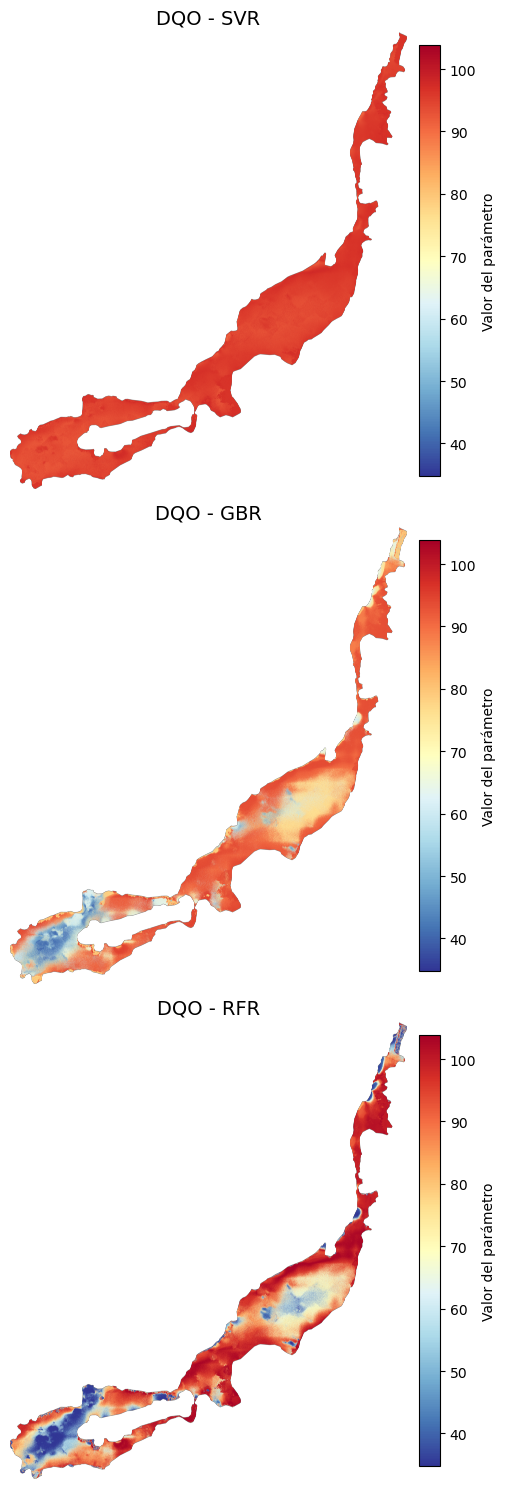

In [9]:
ruta_figura_mapas = (
    BASE_DIR
    / "outputs"
    / "figures"
    / "calidad_agua"
    / target_salida
    / "mapas_prediccion_modelos.png"
)

rasters_prediccion = visualizar_rasters_prediccion(
    rutas_salida=rutas_salida,
    target_salida=target_salida,
    ruta_figura=ruta_figura_mapas,
    cmap="RdYlBu_r",
    usar_percentiles=True,
    pmin=2,
    pmax=98
)

## Productos generados

Para un parámetro como `DQO`, las salidas esperadas son:

- `outputs/rasters/calidad_agua/DQO/DQO_SVR.tif`
- `outputs/rasters/calidad_agua/DQO/DQO_GBR.tif`
- `outputs/rasters/calidad_agua/DQO/DQO_RFR.tif`

Si el modelo fue entrenado sobre una variable transformada como `ln_DQO`, el pipeline convierte automáticamente las predicciones a escala original antes de exportar los raster finales.

## Consideraciones técnicas

- Los tres modelos se aplican sobre el mismo stack predictivo para mantener la comparabilidad espacial.
- Las variables usadas en la predicción deben coincidir con las variables utilizadas durante el entrenamiento.
- Si la variable objetivo del modelo corresponde a una columna transformada con logaritmo natural, como `ln_DQO`, las predicciones se convierten automáticamente a escala original mediante la función exponencial.
- Las salidas raster se organizan usando `target_salida`, por ejemplo `DQO`.
- El límite espacial suministrado permite restringir la predicción al área de interés, por ejemplo el espejo de agua del humedal.
- Los mapas generados representan estimaciones derivadas del modelo, no mediciones directas.

## Cierre del flujo de calidad de agua

Con este notebook se completa el flujo principal del modelo de calidad de agua:

1. extracción de variables espectrales,
2. preparación del dataset de modelado,
3. entrenamiento de modelos,
4. evaluación comparativa,
5. análisis de importancia de variables,
6. predicción espacial multimodelo.

Este flujo permite entrenar, comparar e implementar modelos de estimación de calidad de agua sobre imágenes multiespectrales de humedales.